Processing Descoberto
Available infrastructure IDs in pathway data: [5, 6, 10]
Total records: 2791


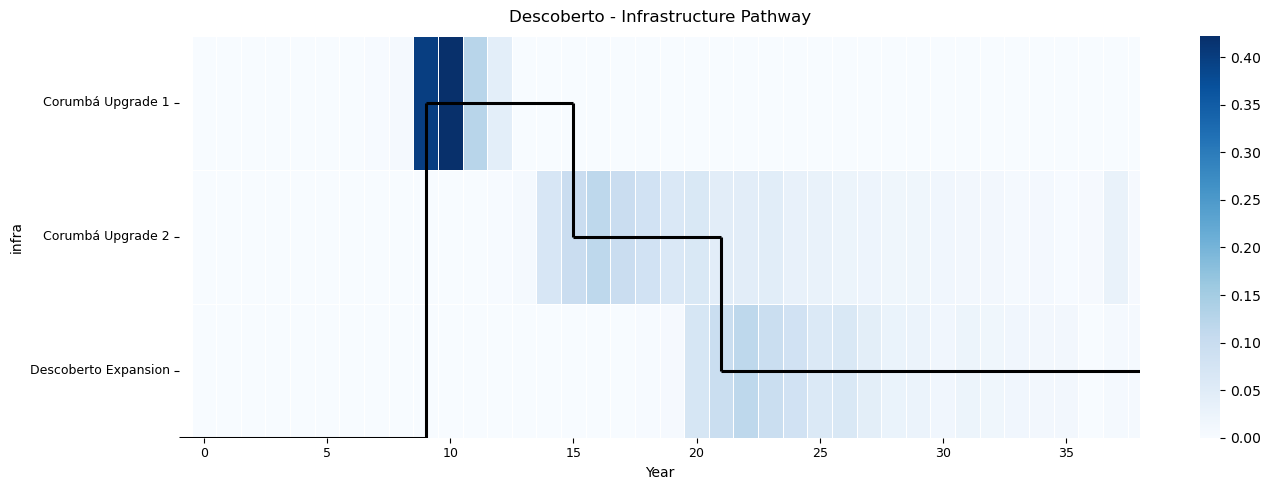

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============== USER SETTINGS =================
file_path = r"C:\PhD_coding\WaterPaths_v01\WaterPaths\WaterPaths_WSS\output\Descoberto_OnInfra\Pathways_s0.out"

util_focus = 0             # 0 = Descoberto, 1 = Torto/Santa Maria
path_real  = 10             # realization ID to draw pathway
cmap       = "Blues"       # heat-map colour

util_name   = {0: "Descoberto", 1: "Torto/Santa Maria"}

# Complete infrastructure list for each WSS (from Caesb.cpp model setup)
infra_order = {
    0: [5, 6, 10],        # Descoberto: ETA Corumbá upgrades + Descoberto expansion
    1: [7, 8, 9],          # Torto/Santa Maria: ETA Paranoá Sul upgrades
}

# Infrastructure names from model setup
infra_name = {
    0: {
        5:  "Corumbá Upgrade 1",
        6:  "Corumbá Upgrade 2",
        10: "Descoberto Expansion"
    },
    1: {
        7:  "Paranoá Upgrade 1",
        8: "Paranoá Upgrade 2",
        9: "Paranoá Upgrade 3"
    },
}

# Fixed x-axis range for consistent comparison
x_axis_years = np.arange(0, 39)  # 0 to 38 years
# ==============================================


# 1) Load & tidy ---------------------------------------------------
df = pd.read_csv(file_path, sep="\t")
df.rename(columns=lambda c: c.strip("."), inplace=True)

# convert 'week' to 'year' and round to integer for consistent binning
df["x"] = np.round(df["week"] / 52.0).astype(int)

# keep only the chosen utility
df = df[df["utility"] == util_focus].copy()

# Check if there's any data
if df.empty:
    print(f"No data found for WSS {util_focus} ({util_name[util_focus]})")
    print(f"Available utilities in the data: {sorted(pd.read_csv(file_path, sep='\\t')['utility'].unique())}")
else:
    print(f"Processing {util_name[util_focus]}")
    print(f"Available infrastructure IDs in pathway data: {sorted(df['infra'].unique())}")
    print(f"Total records: {len(df)}")

# 2) Frequency table ----------------------------------------------
freq = (
    df.groupby(["x", "infra"])
      .size()
      .reset_index(name="count")
)
total_real = df["Realization"].nunique()
freq["frequency"] = freq["count"] / total_real


# 3) Plot ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5), sharex=True)

# ---- heat-map ----------------------------------------------------
heat = freq.pivot_table(index="infra", columns="x",
                        values="frequency", fill_value=0)

# Use the complete infrastructure list from model setup
order = infra_order[util_focus]

# Reindex to include all infrastructure and all years (0-38)
heat = heat.reindex(index=order, columns=x_axis_years, fill_value=0)

vmax = max(0.3, heat.values.max() if heat.values.size > 0 else 0.3)
sns.heatmap(heat, cmap=cmap, vmin=0, vmax=vmax,
            linewidths=.4, linecolor="white",
            ax=ax, cbar=True)

# ---- Set infrastructure names on y-axis --------------------------
ax.set_yticks(np.arange(len(order)) + 0.5)
ax.set_yticklabels([infra_name[util_focus][i] for i in order],
                   rotation=0, fontsize=9)


# 4) Step-style pathway for Realization ----------------------------
if not df.empty and len(heat.columns) > 0:
    # ── helper: convert real year value → heat-map column position
    col_lookup = {val: idx for idx, val in enumerate(heat.columns)}
    
    def col_pos(year):
        return col_lookup.get(year, len(heat.columns) - 1) + 0.5
    
    one         = df[df["Realization"] == path_real]
    first_build = one.groupby("infra")["x"].min()
    
    infra2y = {infra: y_idx + .5 for y_idx, infra in enumerate(order)}
    events   = sorted([(col_pos(yr), infra2y[infra])
                       for infra, yr in first_build.items()
                       if infra in infra2y])
    
    baseline_y = len(order)
    start_x    = -0.5
    start_y    = baseline_y
    last_x     = len(heat.columns) - 0.5
    
    for x_target, y_target in events:
        ax.hlines(y=start_y, xmin=start_x, xmax=x_target,
                  color="black", lw=2.2, zorder=25)
        ax.vlines(x=x_target, ymin=min(start_y, y_target),
                  ymax=max(start_y, y_target),
                  color="black", lw=2.2, zorder=25)
        start_x, start_y = x_target, y_target
    
    ax.hlines(y=start_y, xmin=start_x, xmax=last_x,
              color="black", lw=2.2, zorder=25)
    
    
    # 5) Cosmetics -----------------------------------------------------
    ax.set_xlim(left=-0.5, right=last_x)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_title(f"{util_name[util_focus]} - Infrastructure Pathway",
                 fontsize=12, pad=10)
    
    # --- X-axis ticks every 5 years for 0-38 range ---
    x_tick_positions = [i + 0.5 for i in range(0, 39, 5)]
    x_tick_labels = [f'{i}' for i in range(0, 39, 5)]
    
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels, rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.savefig("pathway_heatmap_Descoberto.png", dpi=300)
    plt.show()
else:
    print("No data to plot pathway")

No data found for WSS 1 (Torto/Santa Maria)
Available utilities in the data: [0]
No data to plot pathway


C:\Users\Moham073\AppData\Local\Temp\ipykernel_37676\2038847636.py:53: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  print(f"Available utilities in the data: {sorted(pd.read_csv(file_path, sep='\\t')['utility'].unique())}")


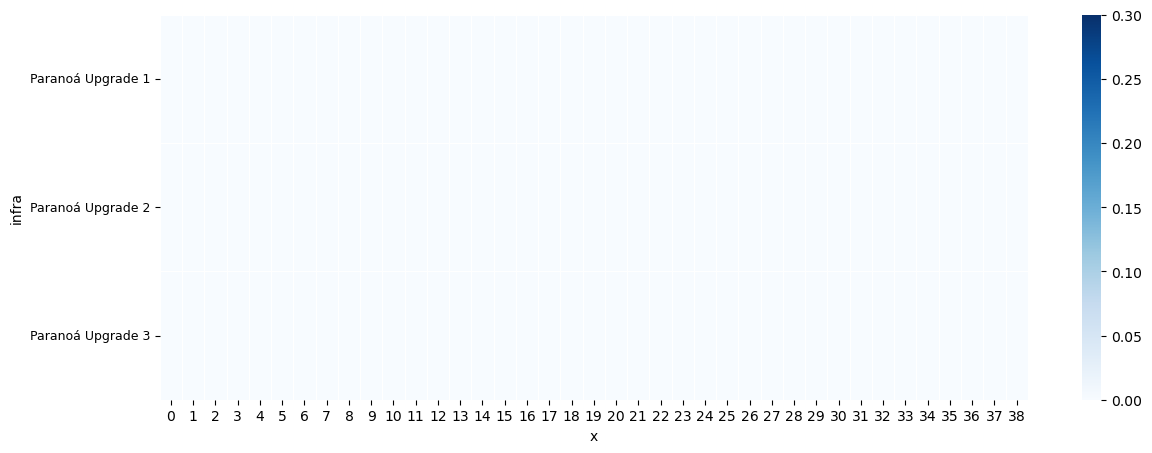

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============== USER SETTINGS =================
file_path = r"C:\PhD_coding\WaterPaths_v01\WaterPaths\Experimental\WaterPaths_WSS_PFC\output\Pathways_s0.out"

util_focus = 1             # 0 = Descoberto, 1 = Torto/Santa Maria
path_real  = 10             # realization ID to draw pathway
cmap       = "Blues"       # heat-map colour

util_name   = {0: "Descoberto", 1: "Torto/Santa Maria"}

# Complete infrastructure list for each WSS (from Caesb.cpp model setup)
infra_order = {
    0: [5, 6, 10],        # Descoberto: ETA Corumbá upgrades + Descoberto expansion
    1: [7, 8, 9],          # Torto/Santa Maria: ETA Paranoá Sul upgrades
}

# Infrastructure names from model setup
infra_name = {
    0: {
        5:  "Corumbá Upgrade 1",
        6:  "Corumbá Upgrade 2",
        10: "Descoberto Expansion"
    },
    1: {
        7:  "Paranoá Upgrade 1",
        8: "Paranoá Upgrade 2",
        9: "Paranoá Upgrade 3"
    },
}

# Fixed x-axis range for consistent comparison
x_axis_years = np.arange(0, 39)  # 0 to 38 years
# ==============================================


# 1) Load & tidy ---------------------------------------------------
df = pd.read_csv(file_path, sep="\t")
df.rename(columns=lambda c: c.strip("."), inplace=True)

# convert 'week' to 'year' and round to integer for consistent binning
df["x"] = np.round(df["week"] / 52.0).astype(int)

# keep only the chosen utility
df = df[df["utility"] == util_focus].copy()

# Check if there's any data
if df.empty:
    print(f"No data found for WSS {util_focus} ({util_name[util_focus]})")
    print(f"Available utilities in the data: {sorted(pd.read_csv(file_path, sep='\\t')['utility'].unique())}")
else:
    print(f"Processing {util_name[util_focus]}")
    print(f"Available infrastructure IDs in pathway data: {sorted(df['infra'].unique())}")
    print(f"Total records: {len(df)}")

# 2) Frequency table ----------------------------------------------
freq = (
    df.groupby(["x", "infra"])
      .size()
      .reset_index(name="count")
)
total_real = df["Realization"].nunique()
freq["frequency"] = freq["count"] / total_real


# 3) Plot ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5), sharex=True)

# ---- heat-map ----------------------------------------------------
heat = freq.pivot_table(index="infra", columns="x",
                        values="frequency", fill_value=0)

# Use the complete infrastructure list from model setup
order = infra_order[util_focus]

# Reindex to include all infrastructure and all years (0-38)
heat = heat.reindex(index=order, columns=x_axis_years, fill_value=0)

vmax = max(0.3, heat.values.max() if heat.values.size > 0 else 0.3)
sns.heatmap(heat, cmap=cmap, vmin=0, vmax=vmax,
            linewidths=.4, linecolor="white",
            ax=ax, cbar=True)

# ---- Set infrastructure names on y-axis --------------------------
ax.set_yticks(np.arange(len(order)) + 0.5)
ax.set_yticklabels([infra_name[util_focus][i] for i in order],
                   rotation=0, fontsize=9)


# 4) Step-style pathway for Realization ----------------------------
if not df.empty and len(heat.columns) > 0:
    # ── helper: convert real year value → heat-map column position
    col_lookup = {val: idx for idx, val in enumerate(heat.columns)}
    
    def col_pos(year):
        return col_lookup.get(year, len(heat.columns) - 1) + 0.5
    
    one         = df[df["Realization"] == path_real]
    first_build = one.groupby("infra")["x"].min()
    
    infra2y = {infra: y_idx + .5 for y_idx, infra in enumerate(order)}
    events   = sorted([(col_pos(yr), infra2y[infra])
                       for infra, yr in first_build.items()
                       if infra in infra2y])
    
    baseline_y = len(order)
    start_x    = -0.5
    start_y    = baseline_y
    last_x     = len(heat.columns) - 0.5
    
    for x_target, y_target in events:
        ax.hlines(y=start_y, xmin=start_x, xmax=x_target,
                  color="black", lw=2.2, zorder=25)
        ax.vlines(x=x_target, ymin=min(start_y, y_target),
                  ymax=max(start_y, y_target),
                  color="black", lw=2.2, zorder=25)
        start_x, start_y = x_target, y_target
    
    ax.hlines(y=start_y, xmin=start_x, xmax=last_x,
              color="black", lw=2.2, zorder=25)
    
    
    # 5) Cosmetics -----------------------------------------------------
    ax.set_xlim(left=-0.5, right=last_x)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_title(f"{util_name[util_focus]} - Infrastructure Pathway",
                 fontsize=12, pad=10)
    
    # --- X-axis ticks every 5 years for 0-38 range ---
    x_tick_positions = [i + 0.5 for i in range(0, 39, 5)]
    x_tick_labels = [f'{i}' for i in range(0, 39, 5)]
    
    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels, rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.savefig("pathway_heatmap_TortoSM.png", dpi=300)
    plt.show()
else:
    print("No data to plot pathway")